In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, f1_score, recall_score, precision_score
import matplotlib.pyplot as plt

### Defining functions

In [2]:
def get_f1_score(data, prediction, label, zero_div = np.nan):
    data = data.copy()
    min_labs = sorted(data["Mineral"].unique())
    mode = "weighted"
    mode1 = "macro"
    macro = f1_score(data["Mineral"],data[prediction], average=mode1, labels = min_labs, zero_division= zero_div)
    weighted = f1_score(data["Mineral"],data[prediction], average=mode, labels = min_labs, zero_division= zero_div)
    overall = pd.DataFrame([macro, weighted], index=["Macro","Weighted"], columns = [label])
    min_f1 = pd.DataFrame(f1_score(data["Mineral"], data[prediction], 
                                   average = None, labels= min_labs, zero_division= zero_div),index=min_labs, columns=[label])
    metric = pd.concat([overall, min_f1], axis = 0).round(3)
    return(metric)

In [3]:
def get_recall_score(data, prediction, label, zero_div = np.nan):
    data = data.copy()
    min_labs = sorted(data["Mineral"].unique())
    mode = "weighted"
    mode1 = "macro"
    macro = recall_score(data["Mineral"],data[prediction], average=mode1, labels = min_labs, zero_division= zero_div)
    weighted = recall_score(data["Mineral"],data[prediction], average=mode, labels = min_labs, zero_division= zero_div)
    overall = pd.DataFrame([macro, weighted], index=["Macro","Weighted"], columns = [label])
    min_f1 = pd.DataFrame(recall_score(data["Mineral"], data[prediction], 
                                   average = None, labels= min_labs, zero_division= zero_div),index=min_labs, columns=[label])
    metric = pd.concat([overall, min_f1], axis = 0).round(3)
    return(metric)    

In [4]:
def get_precision_score(data, prediction, label, zero_div = np.nan):
    data = data.copy()
    min_labs = sorted(data["Mineral"].unique())
    mode = "weighted"
    mode1 = "macro"
    macro = precision_score(data["Mineral"],data[prediction], average=mode1, labels = min_labs, zero_division= zero_div)
    weighted = precision_score(data["Mineral"],data[prediction], average=mode, labels = min_labs, zero_division= zero_div)
    overall = pd.DataFrame([macro, weighted], index=["Macro","Weighted"], columns = [label])
    min_f1 = pd.DataFrame(precision_score(data["Mineral"], data[prediction], 
                                   average = None, labels= min_labs, zero_division= zero_div),index=min_labs, columns=[label])
    metric = pd.concat([overall, min_f1], axis = 0).round(3)
    return(metric)    

In [5]:
data_original = pd.read_excel("Validation data.xlsx",sheet_name="Mist Output vs. true labels",index_col = 0, header = 0)
data_original

,Mineral,SiO2,MgO,FeO,TiO2,Al2O3,MnO,CaO,Na2O,K2O,...,CoO,ZrO2,CuO,CO2,SnO,Total,MIST output,Qmin pred,MinNet pred,Source
S. No.,,,,,,,,,,,,,,,,,,,,,
1979,Als,36.585200,0.000000,0.216700,0.0000,63.876300,0.0000,0.0000,0.0146,0.0000,...,0.0,0.0000,0.0,0.0,0.0,100.731000,??,Fsp,Als,"Arora, D., Pant, N., Pandey, M., Chattopadhyay..."
1980,Als,35.949400,0.023300,0.446100,0.0124,64.317000,0.0000,0.0068,0.0277,0.0000,...,0.0,0.0000,0.0,0.0,0.0,100.937500,??,Fsp,Als,"Arora, D., Pant, N., Pandey, M., Chattopadhyay..."
1981,Als,37.543900,0.000000,0.154600,0.0000,63.258400,0.0000,0.0000,0.0203,0.0000,...,0.0,0.0000,0.0,0.0,0.0,100.977200,??,Fsp,Als,"Arora, D., Pant, N., Pandey, M., Chattopadhyay..."
1982,Als,36.909000,0.027000,0.232000,0.0290,62.443000,0.0160,0.0110,0.0020,0.0130,...,0.0,0.0000,0.0,0.0,0.0,99.682000,??,Fsp,Als,"Arora, D., Pant, N., Pandey, M., Chattopadhyay..."
1983,Als,34.985256,0.062414,0.826559,0.0000,61.593803,0.0000,0.0000,0.0000,0.0000,...,0.0,0.0000,0.0,0.0,0.0,97.695817,??,Fsp,Als,"Arora, D., Pant, N., Pandey, M., Chattopadhyay..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3372,Ttn,28.542900,0.152700,1.569700,33.5035,1.274500,0.0442,27.6428,0.0000,0.0550,...,0.0,1.0342,0.0,0.0,0.0,95.017000,??,Ttn,Ttn,unpublished data
3373,Ttn,29.414600,0.129300,1.620600,33.3730,1.248800,0.0372,28.2707,0.0000,0.0569,...,0.0,0.8948,0.0,0.0,0.0,96.049200,??,Ttn,Ttn,unpublished data
3374,Ttn,29.433200,0.046200,1.546900,33.5335,1.221900,0.0413,27.9436,0.0000,0.0606,...,0.0,0.7742,0.0,0.0,0.0,95.854300,??,Ttn,Ttn,unpublished data


In [6]:
min_labs = sorted(data_original["Mineral"].unique())

## QMin and MinNet

In [7]:
data = data_original.copy()

### Getting common minerals b/w Qmin and MinNet

In [8]:
minerals_to_exclude = ["Crd","Mag/Hem","St","Als","Ctd","Rt"]
data_s = data[~data["Mineral"].isin(minerals_to_exclude)]

### Full dataset

In [9]:
qmin_full_f1 = get_f1_score(data, "Qmin pred", label = "QMin all", zero_div=0)
qmin_full_rec = get_recall_score(data, "Qmin pred", label = "QMin all", zero_div=0)
qmin_full_prec = get_precision_score(data, "Qmin pred", label = "QMin all", zero_div=0)

In [10]:
minnet_full_f1 = get_f1_score(data, "MinNet pred", label = "MinNet all", zero_div=0)
minnet_full_rec = get_recall_score(data, "MinNet pred", label = "MinNet all", zero_div=0)
minnet_full_prec = get_precision_score(data, "MinNet pred", label = "MinNet all", zero_div=0)

In [11]:
qmin_full_rec

,QMin all
Macro,0.650
Weighted,0.821
Als,0.000
Amp,0.478
Ap,0.184
Bt,0.993
Cb,0.872
Crd,0.000
Fsp,0.977
Grt,0.549


### Shared dataset between QMin and MiNnet

In [12]:
qmin_shared_f1 = get_f1_score(data_s, "Qmin pred", label = "QMin shared", zero_div= np.nan)
qmin_shared_rec = get_recall_score(data_s, "Qmin pred", label = "QMin shared", zero_div= np.nan)
qmin_shared_prec = get_precision_score(data_s, "Qmin pred", label = "QMin shared", zero_div= np.nan)

In [13]:
minnet_shared_f1 = get_f1_score(data_s, "MinNet pred", label = "MinNet shared", zero_div= np.nan)
minnet_shared_rec = get_recall_score(data_s, "MinNet pred", label = "MinNet shared", zero_div= np.nan)
minnet_shared_prec = get_precision_score(data_s, "MinNet pred", label = "MinNet shared", zero_div= np.nan)

### Compiling the metrics

In [14]:
f1_qm = pd.concat([qmin_full_f1, minnet_full_f1, qmin_shared_f1, minnet_shared_f1], axis = 1)
rec_qm = pd.concat([qmin_full_rec, minnet_full_rec, qmin_shared_rec, minnet_shared_rec], axis = 1)
prec_qm = pd.concat([qmin_full_prec, minnet_full_prec, qmin_shared_prec, minnet_shared_prec], axis = 1)

In [15]:
prec_qm

,QMin all,MinNet all,QMin shared,MinNet shared
Macro,0.652,0.990,0.889,0.994
Weighted,0.865,0.995,0.949,0.995
Als,0.000,1.000,NaN,NaN
Amp,0.933,0.940,0.933,0.940
Ap,1.000,1.000,1.000,1.000
Bt,1.000,1.000,1.000,1.000
Cb,0.234,1.000,0.234,1.000
Crd,0.000,1.000,NaN,NaN
Fsp,0.952,1.000,0.974,1.000
Grt,0.989,0.988,0.994,0.988


### Exporting the metrics to CSV

In [16]:
# f1_qm.to_csv("F1_score_of_QMin_MinNet_on_validation_dataset.csv")
# rec_qm.to_csv("Recall_score_of_QMin_MinNet_on_validation_dataset.csv")
# prec_qm.to_csv("Precision_score_of_QMin_MinNet_on_validation_dataset.csv")

In [17]:
f1_qm

,QMin all,MinNet all,QMin shared,MinNet shared
Macro,0.613,0.992,0.809,0.994
Weighted,0.815,0.994,0.882,0.994
Als,0.000,1.000,NaN,NaN
Amp,0.632,0.969,0.632,0.969
Ap,0.311,1.000,0.311,1.000
Bt,0.996,1.000,0.996,1.000
Cb,0.370,1.000,0.370,1.000
Crd,0.000,1.000,NaN,NaN
Fsp,0.964,0.995,0.975,0.995
Grt,0.706,0.994,0.708,0.994


In [18]:
col = 3
col = col -1
f1_qm.iloc[2:,col].sum()/f1_qm.iloc[2:,col].count()

0.8093846153846153

In [19]:
prec_qm

,QMin all,MinNet all,QMin shared,MinNet shared
Macro,0.652,0.990,0.889,0.994
Weighted,0.865,0.995,0.949,0.995
Als,0.000,1.000,NaN,NaN
Amp,0.933,0.940,0.933,0.940
Ap,1.000,1.000,1.000,1.000
Bt,1.000,1.000,1.000,1.000
Cb,0.234,1.000,0.234,1.000
Crd,0.000,1.000,NaN,NaN
Fsp,0.952,1.000,0.974,1.000
Grt,0.989,0.988,0.994,0.988


### Confusion matrices

#### Full dataset

<Figure size 6960x9960 with 0 Axes>

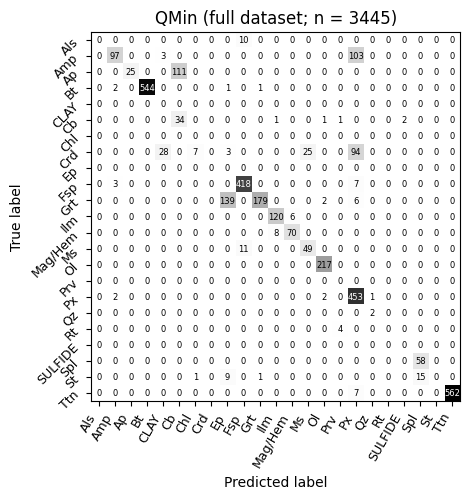

In [20]:
plt.figure(figsize = (5.8,8.3), dpi = 1200)
data_c = data.copy()
ConfusionMatrixDisplay.from_predictions(data_c["Mineral"], data_c["Qmin pred"], 
                                        text_kw = {'fontsize':6}, colorbar=False,
                                       cmap = "grey_r")
plt.xticks(rotation = 60, ha="right", fontsize = 9)
plt.yticks(rotation = 45, ha="right", fontsize = 9)
n = data_c.shape[0]
plt.title(f"QMin (full dataset; n = {n})")
plt.savefig("QMin_cm_QMinvsMinNet_full_dataset.tif",format = "tif", bbox_inches = "tight", dpi = 600)

<Figure size 6960x9960 with 0 Axes>

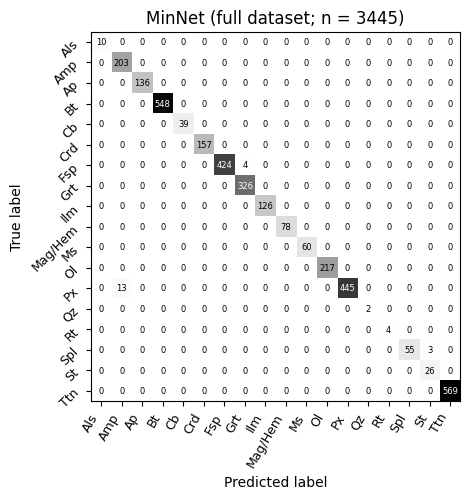

In [21]:
plt.figure(figsize = (5.8,8.3), dpi = 1200)
data_c = data.copy()
ConfusionMatrixDisplay.from_predictions(data_c["Mineral"], data_c["MinNet pred"], 
                                        text_kw = {'fontsize':6}, colorbar=False,
                                       cmap = "grey_r")
plt.xticks(rotation = 60, ha="right", fontsize = 9)
plt.yticks(rotation = 45, ha="right", fontsize = 9)
plt.title(f"MinNet (full dataset; n = {n})")
plt.savefig("MinNet_cm_QMinvsMinNet_full_dataset.tif",format = "tif", bbox_inches = "tight", dpi = 600)

#### Shared dataset

<Figure size 6960x9960 with 0 Axes>

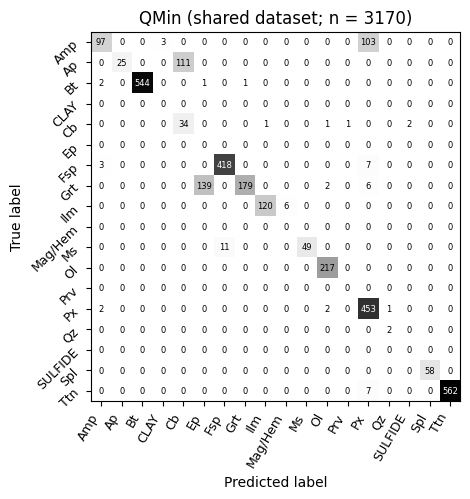

In [22]:
plt.figure(figsize = (5.8,8.3), dpi = 1200)
data_c = data_s.copy()
ConfusionMatrixDisplay.from_predictions(data_c["Mineral"], data_c["Qmin pred"], 
                                        text_kw = {'fontsize':6}, colorbar=False,
                                       cmap = "grey_r")
plt.xticks(rotation = 60, ha="right", fontsize = 9)
plt.yticks(rotation = 45, ha="right", fontsize = 9)
n = data_c.shape[0]
plt.title(f"QMin (shared dataset; n = {n})")
plt.savefig("QMin_cm_QMinvsMinNet_shared_dataset.tif",format = "tif", bbox_inches = "tight", dpi = 600)

<Figure size 6960x9960 with 0 Axes>

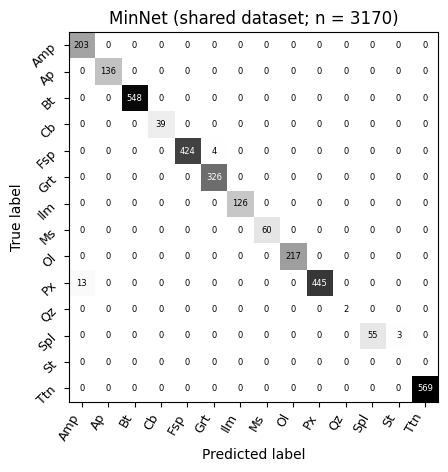

In [23]:
plt.figure(figsize = (5.8,8.3), dpi = 1200)
data_c = data_s.copy()
ConfusionMatrixDisplay.from_predictions(data_c["Mineral"], data_c["MinNet pred"], 
                                        text_kw = {'fontsize':6}, colorbar=False,
                                       cmap = "grey_r")
plt.xticks(rotation = 60, ha="right", fontsize = 9)
plt.yticks(rotation = 45, ha="right", fontsize = 9)
plt.title(f"MinNet (shared dataset; n = {n})")
plt.savefig("MinNet_cm_QMinvsMinNet_shared_dataset.tif",format = "tif", bbox_inches = "tight", dpi = 600)

## MIST and MinNet

In [57]:
data = data_original.copy()

### Getting common minerals b/w MIST and MinNet

In [58]:
data = data[(data["MIST output"] != "??")]
data1_s = data[(data["Mineral"] != "Ttn") & (data["Mineral"] != "Als")]

### Full dataset

In [59]:
mist_full_f1 = get_f1_score(data, "MIST output", label = "MIST all", zero_div=0)
mist_full_rec = get_recall_score(data, "MIST output", label = "MIST all", zero_div=0)
mist_full_prec = get_precision_score(data, "MIST output", label = "MIST all", zero_div=0)

In [60]:
minnet_full_f1 = get_f1_score(data, "MinNet pred", label = "MinNet all", zero_div=0)
minnet_full_rec = get_recall_score(data, "MinNet pred", label = "MinNet all", zero_div=0)
minnet_full_prec = get_precision_score(data, "MinNet pred", label = "MinNet all", zero_div=0)

In [61]:
mist_full_f1

,MIST all
Macro,0.845
Weighted,0.931
Amp,0.810
Ap,1.000
Bt,0.950
Cb,0.984
Crd,1.000
Fsp,0.935
Grt,0.966
Ilm,0.940


### Shared dataset between MIST and MiNnet

In [62]:
mist_shared_f1 = get_f1_score(data1_s, "MIST output", label = "MIST shared", zero_div=np.nan)
mist_shared_rec = get_recall_score(data1_s, "MIST output", label = "MIST shared", zero_div=np.nan)
mist_shared_prec = get_precision_score(data1_s, "MIST output", label = "MIST shared", zero_div=np.nan)

In [63]:
minnet_shared_f1 = get_f1_score(data1_s, "MinNet pred", label = "MinNet shared", zero_div=np.nan)
minnet_shared_rec = get_recall_score(data1_s, "MinNet pred", label = "MinNet shared", zero_div=np.nan)
minnet_shared_prec = get_precision_score(data1_s, "MinNet pred", label = "MinNet shared", zero_div=np.nan)

### Compiling and exporting the metrics

In [64]:
f1_mm = pd.concat([mist_full_f1, minnet_full_f1, mist_shared_f1, minnet_shared_f1], axis = 1)
rec_mm = pd.concat([mist_full_rec, minnet_full_rec, mist_shared_rec, minnet_shared_rec], axis = 1)
prec_mm = pd.concat([mist_full_prec, minnet_full_prec, mist_shared_prec, minnet_shared_prec], axis = 1)

In [65]:
f1_mm

,MIST all,MinNet all,MIST shared,MinNet shared
Macro,0.845,0.992,0.898,0.992
Weighted,0.931,0.995,0.932,0.995
Amp,0.810,0.971,0.810,0.971
Ap,1.000,1.000,1.000,1.000
Bt,0.950,1.000,0.950,1.000
Cb,0.984,1.000,0.984,1.000
Crd,1.000,1.000,1.000,1.000
Fsp,0.935,1.000,0.935,1.000
Grt,0.966,1.000,0.968,1.000
Ilm,0.940,1.000,0.940,1.000


In [66]:
col = 3
col = col -1
f1_mm.iloc[2:,col].sum()/f1_mm.iloc[2:,col].count()

0.8979375

In [67]:
rec_mm

,MIST all,MinNet all,MIST shared,MinNet shared
Macro,0.825,0.995,0.877,0.995
Weighted,0.908,0.995,0.909,0.995
Amp,0.916,1.000,0.916,1.000
Ap,1.000,1.000,1.000,1.000
Bt,0.907,1.000,0.907,1.000
Cb,0.969,1.000,0.969,1.000
Crd,1.000,1.000,1.000,1.000
Fsp,0.878,1.000,0.878,1.000
Grt,0.937,1.000,0.937,1.000
Ilm,0.887,1.000,0.887,1.000


In [68]:
prec_mm

,MIST all,MinNet all,MIST shared,MinNet shared
Macro,0.903,0.990,0.959,0.990
Weighted,0.970,0.995,0.971,0.995
Amp,0.725,0.944,0.725,0.944
Ap,1.000,1.000,1.000,1.000
Bt,0.998,1.000,0.998,1.000
Cb,1.000,1.000,1.000,1.000
Crd,1.000,1.000,1.000,1.000
Fsp,1.000,1.000,1.000,1.000
Grt,0.997,1.000,1.000,1.000
Ilm,1.000,1.000,1.000,1.000


In [69]:
# f1_mm.to_csv("F1_score_of_MIST_MinNet_on_validation_dataset.csv")
# rec_mm.to_csv("Recall_score_of_MIST_MinNet_on_validation_dataset.csv")
# prec_mm.to_csv("Precision_score_of_MIST_MinNet_on_validation_dataset.csv")

## Confusion matrices

### MIST full dataset

<Figure size 6960x9960 with 0 Axes>

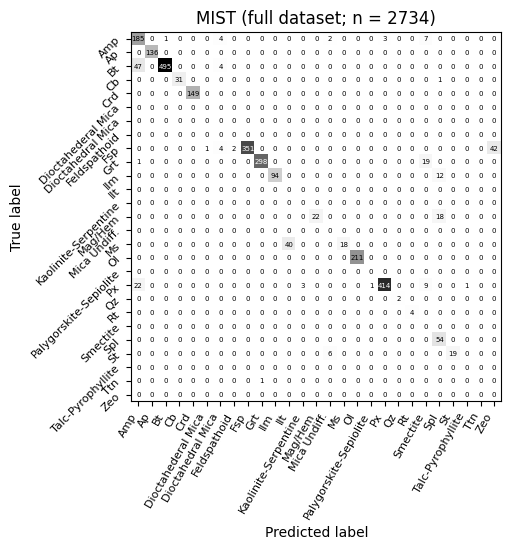

In [70]:
plt.figure(figsize = (5.8,8.3), dpi = 1200)
data_c = data.copy()
ConfusionMatrixDisplay.from_predictions(data_c["Mineral"], data_c["MIST output"], 
                                        text_kw = {'fontsize':5}, colorbar=False,
                                       cmap = "grey_r")
plt.xticks(rotation = 60, ha="right", fontsize = 8)
plt.yticks(rotation = 45, ha="right", fontsize = 8)
n = data_c.shape[0]
plt.title(f"MIST (full dataset; n = {n})")
plt.savefig("MIST_cm_MISTvsMinNet_full_dataset.tif",format = "tif", bbox_inches = "tight", dpi = 600)

<Figure size 6960x9960 with 0 Axes>

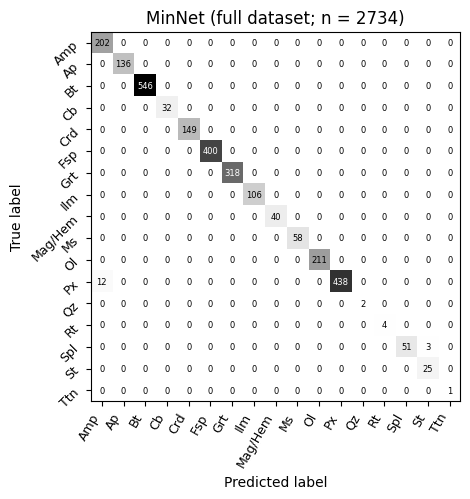

In [71]:
plt.figure(figsize = (5.8,8.3), dpi = 1200)
data_c = data.copy()
ConfusionMatrixDisplay.from_predictions(data_c["Mineral"], data_c["MinNet pred"], 
                                        text_kw = {'fontsize':6}, colorbar=False,
                                       cmap = "grey_r")
plt.xticks(rotation = 60, ha="right", fontsize = 9)
plt.yticks(rotation = 45, ha="right", fontsize = 9)
plt.title(f"MinNet (full dataset; n = {n})")
plt.savefig("MinNet_cm_MISTvsMinNet_full_dataset.tif",format = "tif", bbox_inches = "tight", dpi = 600)

### MIST shared dataset

<Figure size 6960x9960 with 0 Axes>

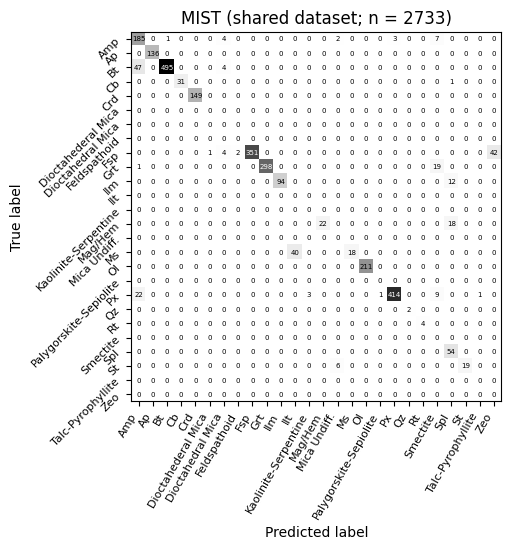

In [72]:
plt.figure(figsize = (5.8,8.3), dpi = 1200)
data_c = data1_s.copy()
n = data_c.shape[0]
ConfusionMatrixDisplay.from_predictions(data_c["Mineral"], data_c["MIST output"], 
                                        text_kw = {'fontsize':5}, colorbar=False,
                                       cmap = "grey_r")
plt.xticks(rotation = 60, ha="right", fontsize = 8)
plt.yticks(rotation = 45, ha="right", fontsize = 8)
plt.title(f"MIST (shared dataset; n = {n})")
plt.savefig("MIST_cm_MISTvsMinNet_shared_dataset.tif",format = "tif", bbox_inches = "tight", dpi = 600)

<Figure size 6960x9960 with 0 Axes>

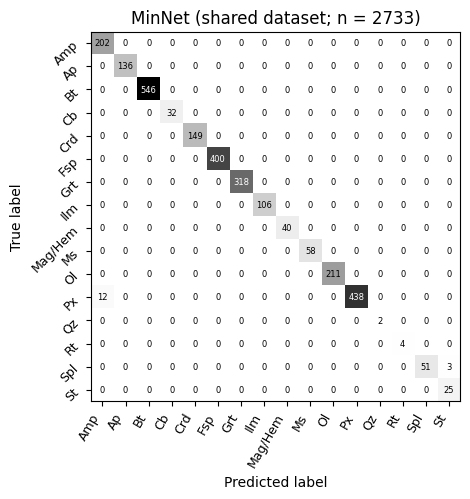

In [73]:
plt.figure(figsize = (5.8,8.3), dpi = 1200)
data_c = data1_s.copy()
ConfusionMatrixDisplay.from_predictions(data_c["Mineral"], data_c["MinNet pred"], 
                                        text_kw = {'fontsize':6}, colorbar=False,
                                       cmap = "grey_r")
plt.xticks(rotation = 60, ha="right", fontsize = 9)
plt.yticks(rotation = 45, ha="right", fontsize = 9)
plt.title(f"MinNet (shared dataset; n = {n})")
plt.savefig("MinNet_cm_MISTvsMinNet_shared_dataset.tif",format = "tif", bbox_inches = "tight", dpi = 600)